# Slow farmer Kolmogorov equations for $N_w$ and $N_g$

In [1]:
import matplotlib as mpl
from matplotlib import pyplot as plt
import scipy as sp
import numpy as np

import pickle
import time

In [2]:
print("Last run: " + time.ctime())

Last run: Thu Jan 18 19:04:19 2024


In [3]:
#set serif font
plt.rcParams["font.family"]="serif"
plt.rcParams["mathtext.fontset"]="dejavuserif"

In [4]:
#colorblind optimized color cycle
#https://doi.org/10.1038/nmeth.1618
wong_colors = ["#000000", "#E69F00",
               "#56B4e9", "#009E73",
               "#F0E442", "#0072B2",
               "#D55E00", "#CC79A7"]
wong_cycle = mpl.rcsetup.cycler(color=wong_colors)

In [5]:
R = 0.00888
K = 0.00772

## setting up system

In [6]:
def timeToIndex(ar, t):
    """given array of times, ar, returns the largest index i such that ar[i]<=t"""

    if ar[-1] < t:
        raise IndexError("Time t is out of bounds of array ar")
        
    i = 0
    while ar[i+1] <= t:
        i += 1
    return i

In [7]:
def pmfE(p):
    """calculate the expected value of the pmf p
    p should be a vector where p[i] represents the probability of state x=i"""

    return np.sum(p * np.arange(0, p.size))

def pmfVar(p):
    """calculate the variance of the pmf p
    p should be a vector where p[i] represents the probability of state x=i"""
    return np.sum(p*(np.arange(0, p.size)-pmfE(p))**2)

In [8]:
def growthRate(Ng, N, A):
    return K*Ng*(1-Ng/A)

def eatRate(Ng, N, A):
    return N*R*Ng/A

In [9]:
#s matrix elements

def s_ijkl(i, j, k, l, N, A):

    if i == k and j == l:
        return -growthRate(i, N, A) - eatRate(i, N, A)
    elif i == k-1 and j == l:
        return growthRate(k-1, N, A)
    elif i == k+1 and j == l:
        return eatRate(k+1, N, A)*l/N
    elif i == k+1 and j == l-1:
        return eatRate(k+1, N, A)*(N-l+1)/N
    else:
        return 0

In [10]:
def sMatrix(N, A):
    s_matrix = np.zeros((A+1, N+1, A+1, N+1))
    for i in range(A+1):
        for j in range(N+1):
            for k in range(A+1):
                for l in range(N+1):
                    s_matrix[i,j,k,l] = s_ijkl(i, j, k, l, N, A)
    return s_matrix

In [11]:
def sFlatten(s):
    """accepts matrix of shape (A+1, N+1, A+1, N+1)
    reshape into matrix of shape ( (A+1)(N+1), (A+1)(N+1) )
    does not need N and A passed to it because dimensions can be grabbed
    from s.shape
    """

    #dim = (A+1)(N+1)
    dim = s.shape[0]*s.shape[1]

    #fortran order
    return np.reshape(s, (dim, dim), "f")

def qFlatten(q):
    """accepts matrix of shape (A+1, N+1)
    reshape into matrix of shape (A+1)*(N+1)
    """

    dim = q.shape[0]*q.shape[1]

    return np.reshape(q, (dim), "f")

def qExpand(q, N, A):
    """accepts q vector of shape (A+1)*(N+1)
    reshape into matrix (A+1, N+1)
    needs N and A passed to it
    """

    return np.reshape(q, (A+1, N+1), "f")

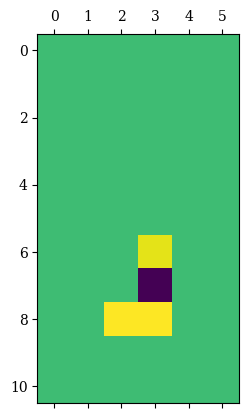

In [12]:
f, ax = plt.subplots()

ax.matshow(sMatrix(5, 10)[:, :, 7, 3])

## quasi-equilibrium distribution
used for initial condition for slow farmer

In [13]:
def quasiEqRec(A, N):
    mat = np.zeros((A, A))
    for i in range(1, A):
        #each loop inserts equation p_i+1 mu_i+1 - p_i lambda_i = 0
        mat[i-1, i] = eatRate(i+1, N, A)
        mat[i-1, i-1] = -growthRate(i, N, A)

    #final row for probability=1 equation
    for i in range(0, A):
        mat[-1, i] = 1

    #dependent variable vector
    b = np.zeros(A)
    b[-1]=1

    #concatenate a zero to the beginning to represent p_0=0
    #important for use with pmfE() and pmfVar(), which assume that p_i appears at index i
    return np.concatenate((np.array([0]), np.linalg.solve(mat, b)))

## setting up simulation

requires fast farmer to have been run

In [14]:
def getInit(N):
    """fetch the numerical solution for the N_g distribution from the fast farmer kolmogorov equations"""

    with open("kolmogorov_sol_100.dat", "rb") as f:
        sol_100 = pickle.load(f)

    #get the solution at t=10000
    return sol_100[str(N)]["y"][:,-1]

In [15]:
def simulate(N, A, stoptime, init="quasi"):

    s_matrix = sMatrix(N, A)

    q0 = np.zeros((A+1, N+1))
    #begin pasture Nw=0
    #and Ng is quasi-equilibrium
    #meaning q_x,0 = p_x at equilibrium
    if init=="quasi":
        q0[:,0]=getInit(N)
    elif init=="max":
        q0[A,0]=1

    #need to reshape to work with solve_ivp
    #fortran order - first index changes fastest
    s_matrix = sFlatten(s_matrix)
    q0 = np.reshape(q0, ((N+1)*(A+1)), order="F")

    def sys(t, y):
        return np.matmul(y, s_matrix)

    #t_list needs to be specified here to ensure dense data at small T
    #we are gonna be interested in computing F_slow at T=1 and if we don't
    #specify t_list, we will not have points sufficiently close to T=1
    t_list = np.concatenate((np.arange(0, 11), np.arange(20, 100, 10), np.arange(100, stoptime+1, 100)))
    
    st = time.time()

    s = sp.integrate.solve_ivp(sys, (0, stoptime), q0, method="RK23", t_eval=t_list)
    print("finished A={0}, N={1} in {2} seconds".format(A, N, time.time()-st))

    return s

## simpler plot of q evolution

In [16]:
sol = simulate(15, 30, 1000, "max")

data1 = qExpand(sol["y"][
                   :,timeToIndex(
                       sol["t"], 20)], 15, 30)

data2 = qExpand(sol["y"][
                   :,timeToIndex(
                       sol["t"], 100)], 15, 30)

data3 = qExpand(sol["y"][
                   :,timeToIndex(
                       sol["t"], 500)], 15, 30)

finished A=30, N=15 in 0.26188111305236816 seconds


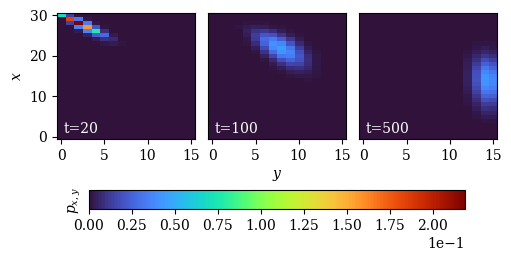

In [17]:
f, axs = plt.subplots(ncols=3, figsize=(5, 2.5), layout="constrained")

vm = np.max([
    data1,
    data2,
    data3])

ptr = axs[0].imshow(data1, aspect="auto", origin="lower", vmax=vm, cmap="turbo")
axs[1].imshow(data2, aspect="auto", origin="lower", vmax=vm, cmap="turbo")
axs[2].imshow(data3, aspect="auto", origin="lower", vmax=vm, cmap="turbo")

axs[1].set_xlabel("$y$")
axs[0].set_ylabel("$x$")
axs[1].set_yticks([])
axs[2].set_yticks([])

axs[0].set_xticks([0, 5, 10, 15])
axs[1].set_xticks([0, 5, 10, 15])
axs[2].set_xticks([0, 5, 10, 15])

axs[0].annotate("t=20", (0.05, 0.05), xycoords="axes fraction", color="white")
axs[1].annotate("t=100", (0.05, 0.05), xycoords="axes fraction", color="white")
axs[2].annotate("t=500", (0.05, 0.05), xycoords="axes fraction", color="white")

cb = plt.colorbar(ptr, ax=axs, location="bottom")
cb.formatter.set_powerlimits((-1, 5))
cb.ax.set_ylabel("$p_{x,y}$")

plt.savefig("p_nw_evolution.pdf")

## Simulate a range of pastures

In [18]:
#like for grass model, test values of N from 0.05A up to 0.85A in increments of 0.05A
#test only A=100
#test out to t=1600

sol_100 = {str(i): simulate(i, 100, 1600) for i in range(5, 90, 5)}

finished A=100, N=5 in 0.05065107345581055 seconds
finished A=100, N=10 in 0.20745158195495605 seconds
finished A=100, N=15 in 1.0015485286712646 seconds
finished A=100, N=20 in 2.37208890914917 seconds
finished A=100, N=25 in 3.96755313873291 seconds
finished A=100, N=30 in 5.819404125213623 seconds
finished A=100, N=35 in 9.247233629226685 seconds
finished A=100, N=40 in 12.164776802062988 seconds
finished A=100, N=45 in 16.37660837173462 seconds
finished A=100, N=50 in 21.615150928497314 seconds
finished A=100, N=55 in 27.635180473327637 seconds
finished A=100, N=60 in 34.78669857978821 seconds
finished A=100, N=65 in 41.79502820968628 seconds
finished A=100, N=70 in 50.03552746772766 seconds
finished A=100, N=75 in 62.44274973869324 seconds
finished A=100, N=80 in 70.29156184196472 seconds
finished A=100, N=85 in 82.90437936782837 seconds


In [19]:
with open("slow_sol_100.dat", "wb") as f:
    pickle.dump(sol_100, f)